In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

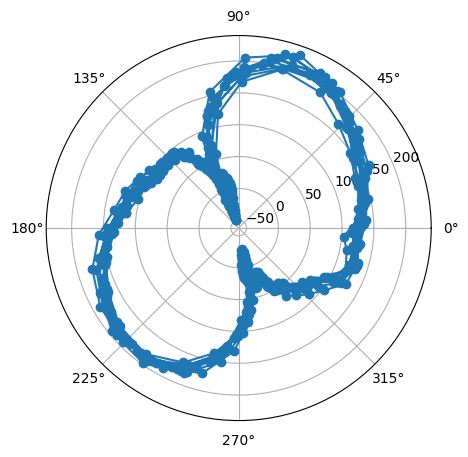

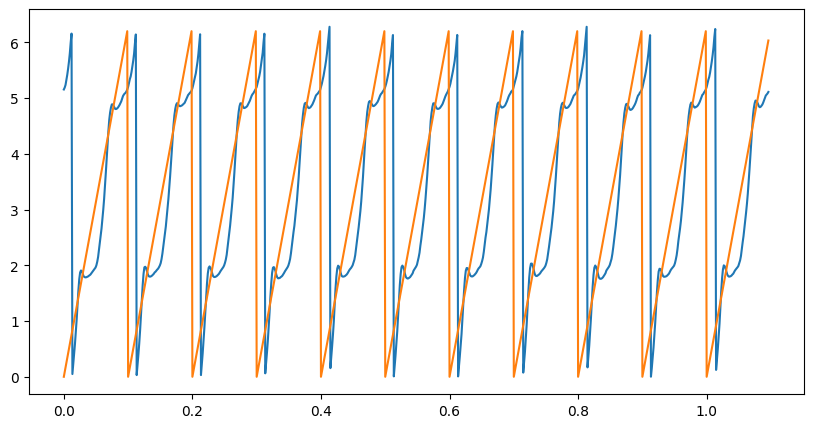

In [3]:
filenames = ["locomotion/d10hz1-1.csv", "locomotion/d10hz2-2.csv"]
dfs = [pd.read_csv(filename, header=1) for filename in filenames]
for df in dfs:
    df.columns = ['time', 'x', 'y', 'theta', 'omega', 'alpha']

w_field = 10 # Hz 
w_field = 2 * np.pi * w_field

min_length = min([len(df) for df in dfs])

ts = (dfs[0]['time'].values[:min_length] + dfs[1]['time'].values[:min_length])/2
theta_field = w_field * ts
thetas = (dfs[0]['theta'].values[:min_length] + dfs[1]['theta'].values[:min_length])/2
thetas = thetas * np.pi / 180
omegas = (dfs[0]['omega'].values[:min_length] + dfs[1]['omega'].values[:min_length])/2    
omegas = omegas * np.pi / 180

# polar plot of theta vs omega
plt.figure(figsize=(5, 5))
plt.polar(thetas, omegas, '-o')
plt.show()

# plot of theta vs time
plt.figure(figsize=(10, 5))
thetas_wrapped = thetas % (2 * np.pi)
field_wrapped = theta_field % (2 * np.pi)
plt.plot(ts, thetas_wrapped)
plt.plot(ts, field_wrapped)

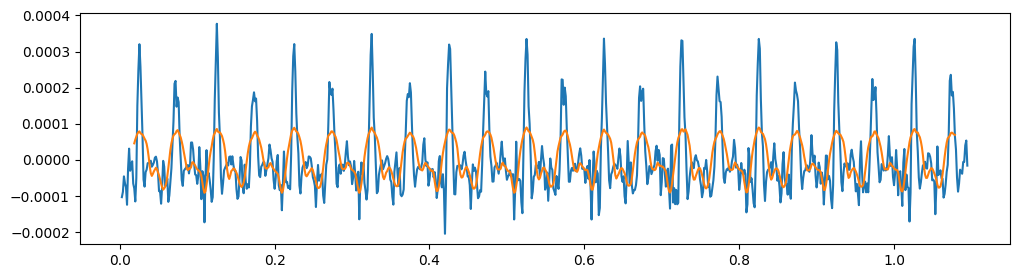

In [4]:
m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 1e-6
wb = 10 * 2 * np.pi

dt = ts[1] - ts[0]
theta_dd = np.diff(omegas)/(dt**2)

F_hat = B*np.sin(theta_field[1:] - thetas[1:]) - J*theta_dd

from scipy.signal import savgol_filter

# Savitzky-Golay filter (good for preserving peaks)
F_hat_filtered = savgol_filter(F_hat, window_length=25, polyorder=3)

plt.figure(figsize=(12, 3))
plt.plot(ts[1:], F_hat)
plt.plot(ts[1:], F_hat_filtered)
plt.show()



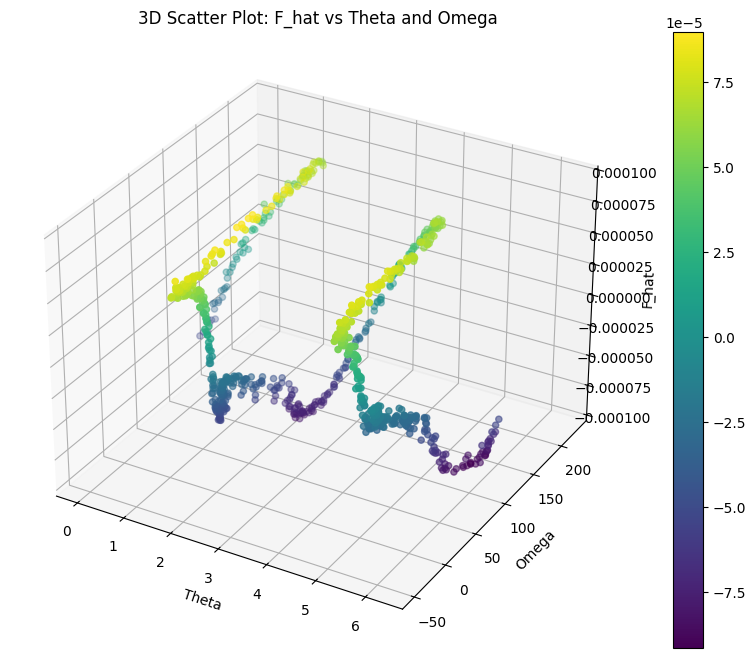

In [5]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

theta = thetas[1:]
# wrap theta 
theta = theta % (2 * np.pi)
omega = omegas[1:]
f_hat = F_hat_filtered

# Create a scatter plot colored by f_hat values
scatter = ax.scatter(theta, omega, f_hat, c=f_hat, cmap='viridis', s=20)

ax.set_xlabel('Theta')
ax.set_ylabel('Omega')
ax.set_zlabel('F_hat')
ax.set_title('3D Scatter Plot: F_hat vs Theta and Omega')

# Add colorbar
plt.colorbar(scatter)
plt.show()

In [37]:
# Alternative approach: Use scikit-learn for polynomial regression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Prepare the data
X = np.column_stack([theta, omega])  # Input variables
y = f_hat  # Output variable (force)

print(f"Data shape before cleaning: X = {X.shape}, y = {y.shape}")

# Check for NaN values and clean the data
print(f"NaN values in X: {np.isnan(X).sum()}")
print(f"NaN values in y: {np.isnan(y).sum()}")

# Remove rows with NaN values
valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]

print(f"Data shape after cleaning: X = {X_clean.shape}, y = {y_clean.shape}")
print(f"Removed {len(X) - len(X_clean)} rows with NaN values")

# Check the scale of the data
print(f"\nData statistics:")
print(f"theta range: [{X_clean[:, 0].min():.3f}, {X_clean[:, 0].max():.3f}]")
print(f"omega range: [{X_clean[:, 1].min():.3f}, {X_clean[:, 1].max():.3f}]")
print(f"f_hat range: [{y_clean.min():.6f}, {y_clean.max():.6f}]")

# Create polynomial features and fit models with scaling
models = {
    'Lasso (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('lasso', Lasso(alpha=0.001, max_iter=2000))
    ]),
    'Ridge (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('ridge', Ridge(alpha=0.001))
    ])
}

best_model = None
best_r2 = -np.inf
best_name = ""

print("\nTesting different models:")
print("-" * 40)

for name, model in models.items():
    model.fit(X_clean, y_clean)
    y_pred = model.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    
    print(f"{name:15} R² = {r2:.4f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_name = name

print("-" * 40)
print(f"Best model: {best_name} with R² = {best_r2:.4f}")

# Get feature names and coefficients
poly_features = best_model.named_steps['poly']
feature_names = poly_features.get_feature_names_out(['theta', 'omega'])
coefficients = best_model.named_steps[best_name.split()[0].lower()].coef_

print(f"\nFeature names: {feature_names}")
print(f"Coefficients: {coefficients}")

min_coef = 1e-5

# Create the equation string with proper scientific notation
equation_parts = []
for i, (coef, feature) in enumerate(zip(coefficients, feature_names)):
    if abs(coef) > min_coef:  # Only include significant terms
        if i == 0 or coef < 0:
            equation_parts.append(f"{coef:.2e}*{feature}")
        else:
            equation_parts.append(f"+ {coef:.2e}*{feature}")

equation = "f_hat = " + " ".join(equation_parts)
print(f"\nDiscovered equation:")
print(equation)

# Show the most important terms with scientific notation
print(f"\nMost important terms (|coefficient| > {min_coef}):")
important_terms = []
for coef, feature in zip(coefficients, feature_names):
    if abs(coef) > min_coef:
        important_terms.append((abs(coef), coef, feature))

important_terms.sort(reverse=True)  # Sort by absolute coefficient value
for abs_coef, coef, feature in important_terms[:10]:  # Show top 10
    print(f"  {coef:12.2e} * {feature}")

Data shape before cleaning: X = (822, 2), y = (822,)
NaN values in X: 1
NaN values in y: 26
Data shape after cleaning: X = (796, 2), y = (796,)
Removed 26 rows with NaN values

Data statistics:
theta range: [0.001, 6.279]
omega range: [-48.526, 226.250]
f_hat range: [-0.000091, 0.000090]

Testing different models:
----------------------------------------
Lasso (L1)      R² = 0.0000
Ridge (L2)      R² = 0.5006
----------------------------------------
Best model: Ridge (L2) with R² = 0.5006

Feature names: ['1' 'theta' 'omega' 'theta^2' 'theta omega' 'omega^2' 'theta^3'
 'theta^2 omega' 'theta omega^2' 'omega^3']
Coefficients: [ 0.00000000e+00  3.42514554e-05 -2.86757659e-05 -3.23485041e-05
  4.77877557e-06  3.55528129e-05 -1.63573259e-05  1.46720724e-05
 -4.79833673e-06 -3.80501016e-06]

Discovered equation:
f_hat = + 3.43e-05*theta -2.87e-05*omega -3.23e-05*theta^2 + 3.56e-05*omega^2 -1.64e-05*theta^3 + 1.47e-05*theta^2 omega

Most important terms (|coefficient| > 1e-05):
      3.56e-0

Prediction shape: (796,)
Original f_hat shape: (796,)
R-squared: 0.5006


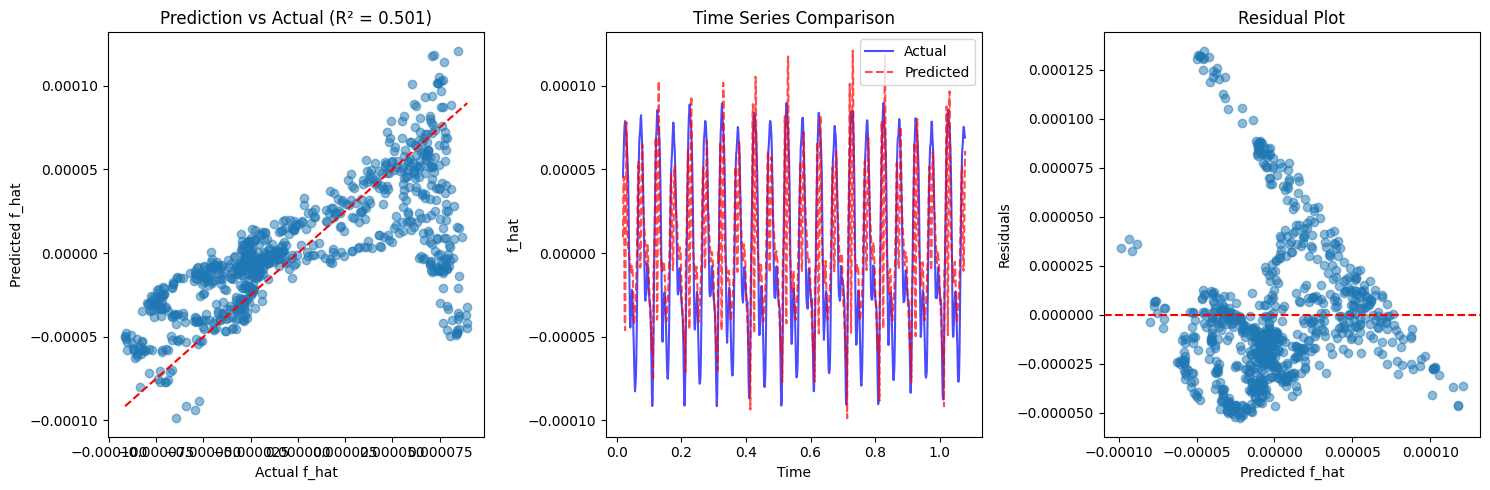


Most important terms (|coefficient| > 0.001):


In [38]:
# Test the discovered model
try:
    f_hat_predicted = best_model.predict(X_clean)
    print(f"Prediction shape: {f_hat_predicted.shape}")
    print(f"Original f_hat shape: {y_clean.shape}")
    
    # Calculate R-squared
    r_squared = r2_score(y_clean, f_hat_predicted)
    print(f"R-squared: {r_squared:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_clean, f_hat_predicted, alpha=0.5)
    plt.plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], 'r--')
    plt.xlabel('Actual f_hat')
    plt.ylabel('Predicted f_hat')
    plt.title(f'Prediction vs Actual (R² = {r_squared:.3f})')
    
    plt.subplot(1, 3, 2)
    # Use the cleaned time indices
    ts_clean = ts[1:][valid_mask]
    plt.plot(ts_clean, y_clean, 'b-', label='Actual', alpha=0.7)
    plt.plot(ts_clean, f_hat_predicted, 'r--', label='Predicted', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('f_hat')
    plt.title('Time Series Comparison')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    residuals = y_clean - f_hat_predicted
    plt.scatter(f_hat_predicted, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted f_hat')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    
    plt.tight_layout()
    plt.show()
    
    # Show the most important terms
    print(f"\nMost important terms (|coefficient| > 0.001):")
    important_terms = []
    for coef, feature in zip(coefficients, feature_names):
        if abs(coef) > 0.001:
            important_terms.append((abs(coef), coef, feature))
    
    important_terms.sort(reverse=True)  # Sort by absolute coefficient value
    for abs_coef, coef, feature in important_terms[:10]:  # Show top 10
        print(f"  {coef:8.4f} * {feature}")
    
except Exception as e:
    print(f"Error in prediction: {e}")
    print(f"Best model: {best_name}")
    print(f"X_clean shape: {X_clean.shape}, y_clean shape: {y_clean.shape}")


In [36]:
# Try different scikit-learn configurations to find the best model
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

configurations = [
    {"name": "Lasso deg 2", "degree": 2, "model": Lasso(alpha=0.001, max_iter=2000)},
    {"name": "Lasso deg 3", "degree": 3, "model": Lasso(alpha=0.001, max_iter=2000)},
    {"name": "Lasso deg 4", "degree": 4, "model": Lasso(alpha=0.001, max_iter=2000)},
    {"name": "Ridge deg 2", "degree": 2, "model": Ridge(alpha=0.001)},
    {"name": "Ridge deg 3", "degree": 3, "model": Ridge(alpha=0.001)},
    {"name": "Ridge deg 4", "degree": 4, "model": Ridge(alpha=0.001)},
    {"name": "ElasticNet deg 3", "degree": 3, "model": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=2000)},
]

best_r2 = -np.inf
best_model = None
best_name = ""

print("Testing different scikit-learn configurations:")
print("-" * 50)

for config in configurations:
    model_test = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=config["degree"])),
        ('regressor', config["model"])
    ])
    
    model_test.fit(X_clean, y_clean)
    f_hat_pred = model_test.predict(X_clean)
    
    r2 = r2_score(y_clean, f_hat_pred)
    
    print(f"{config['name']:20} R² = {r2:.4f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_test
        best_name = config["name"]

print("-" * 50)
print(f"Best model: {best_name} with R² = {best_r2:.4f}")

# Get the best model's equation
poly_features = best_model.named_steps['poly']
feature_names = poly_features.get_feature_names_out(['theta', 'omega'])
coefficients = best_model.named_steps['regressor'].coef_

print(f"\nBest model equation:")
equation_parts = []
for i, (coef, feature) in enumerate(zip(coefficients, feature_names)):
    if abs(coef) > 1e-10:  # Only include significant terms
        if i == 0 or coef < 0:
            equation_parts.append(f"{coef:.2e}*{feature}")
        else:
            equation_parts.append(f"+ {coef:.2e}*{feature}")

equation = "f_hat = " + " ".join(equation_parts)
print(equation)

# Show the most important terms
print(f"\nMost important terms (|coefficient| > 1e-10):")
important_terms = []
for coef, feature in zip(coefficients, feature_names):
    if abs(coef) > 1e-10:
        important_terms.append((abs(coef), coef, feature))

important_terms.sort(reverse=True)  # Sort by absolute coefficient value
for abs_coef, coef, feature in important_terms[:10]:  # Show top 10
    print(f"  {coef:12.2e} * {feature}")

# Additional analysis: Check if the relationship is actually linear
print(f"\nAdditional Analysis:")
print(f"Correlation between theta and f_hat: {np.corrcoef(X_clean[:, 0], y_clean)[0, 1]:.4f}")
print(f"Correlation between omega and f_hat: {np.corrcoef(X_clean[:, 1], y_clean)[0, 1]:.4f}")
print(f"Correlation between theta and omega: {np.corrcoef(X_clean[:, 0], X_clean[:, 1])[0, 1]:.4f}")


Testing different scikit-learn configurations:
--------------------------------------------------
Lasso deg 2          R² = 0.0000
Lasso deg 3          R² = 0.0000
Lasso deg 4          R² = 0.0000
Ridge deg 2          R² = 0.4521
Ridge deg 3          R² = 0.5006
Ridge deg 4          R² = 0.6546
ElasticNet deg 3     R² = 0.0000
--------------------------------------------------
Best model: Ridge deg 4 with R² = 0.6546

Best model equation:
f_hat = + 7.01e-05*theta -1.98e-05*omega + 1.15e-04*theta^2 -2.01e-05*theta omega + 6.36e-05*omega^2 -6.66e-05*theta^3 + 5.16e-05*theta^2 omega -9.26e-08*theta omega^2 -1.32e-05*omega^3 -4.67e-05*theta^4 + 3.42e-05*theta^3 omega -2.94e-05*theta^2 omega^2 -3.97e-06*theta omega^3 -7.27e-07*omega^4

Most important terms (|coefficient| > 1e-10):
      1.15e-04 * theta^2
      7.01e-05 * theta
     -6.66e-05 * theta^3
      6.36e-05 * omega^2
      5.16e-05 * theta^2 omega
     -4.67e-05 * theta^4
      3.42e-05 * theta^3 omega
     -2.94e-05 * theta^2 ome

In [45]:
# Add trigonometric features focused on 10 Hz frequency
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Custom transformer for 10 Hz sine features
class Sine10HzFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, include_cross_terms=True):
        self.include_cross_terms = include_cross_terms
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_sine = X.copy()
        
        # 10 Hz frequency (2*pi*10 = 62.83 rad/s)
        freq = 2 * np.pi * 10
        
        # Sine terms for theta and omega at 10 Hz
        X_sine = np.column_stack([X_sine, np.sin(freq * X[:, 0])])  # sin(10*2π*theta)
        X_sine = np.column_stack([X_sine, np.sin(freq * X[:, 1])])  # sin(10*2π*omega)
        
        if self.include_cross_terms:
            # Cross terms
            X_sine = np.column_stack([X_sine, np.sin(freq * X[:, 0]) * np.sin(freq * X[:, 1])])
            X_sine = np.column_stack([X_sine, np.sin(freq * X[:, 0]) * X[:, 1]])  # sin(10*2π*theta) * omega
            X_sine = np.column_stack([X_sine, X[:, 0] * np.sin(freq * X[:, 1])])  # theta * sin(10*2π*omega)
        
        return X_sine

# Create models with polynomial + 10 Hz sine features
models_combined = {
    'Poly + Sine10Hz': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('sine', Sine10HzFeatures(include_cross_terms=True)),
        ('lasso', Lasso(alpha=0.001, max_iter=2000))
    ]),
    'Poly + Sine10Hz Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('sine', Sine10HzFeatures(include_cross_terms=True)),
        ('ridge', Ridge(alpha=0.001))
    ]),
    'Poly + Sine10Hz (no cross)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('sine', Sine10HzFeatures(include_cross_terms=False)),
        ('lasso', Lasso(alpha=0.001, max_iter=2000))
    ]),
    'Sine10Hz only': Pipeline([
        ('scaler', StandardScaler()),
        ('sine', Sine10HzFeatures(include_cross_terms=True)),
        ('lasso', Lasso(alpha=0.001, max_iter=2000))
    ]),
    'Poly only (for comparison)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)),
        ('lasso', Lasso(alpha=0.001, max_iter=2000))
    ])
}

best_model_combined = None
best_r2_combined = -np.inf
best_name_combined = ""

print("Testing polynomial + 10 Hz sine models:")
print("-" * 60)

for name, model in models_combined.items():
    model.fit(X_clean, y_clean)
    y_pred = model.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    
    print(f"{name:30} R² = {r2:.4f}")
    
    if r2 > best_r2_combined:
        best_r2_combined = r2
        best_model_combined = model
        best_name_combined = name

print("-" * 60)
print(f"Best combined model: {best_name_combined} with R² = {best_r2_combined:.4f}")

# Compare with previous models
print(f"\nModel Comparison:")
print(f"Polynomial only: R² = {best_r2:.4f}")
print(f"Trigonometric (multi-freq): R² = {best_r2_trig:.4f}")
print(f"Polynomial + 10Hz sine: R² = {best_r2_combined:.4f}")

# Get feature names and coefficients for the best combined model
feature_names_combined = []

# Add polynomial feature names
if 'poly' in best_model_combined.named_steps:
    poly_features = best_model_combined.named_steps['poly']
    poly_names = poly_features.get_feature_names_out(['theta', 'omega'])
    feature_names_combined.extend(poly_names)

# Add sine feature names
if 'sine' in best_model_combined.named_steps:
    sine_names = [
        'sin(10*2π*theta)', 'sin(10*2π*omega)',
        'sin(10*2π*theta)*sin(10*2π*omega)',
        'sin(10*2π*theta)*omega', 'theta*sin(10*2π*omega)'
    ]
    feature_names_combined.extend(sine_names)

# Get coefficients from the correct step (the regression model)
regressor_name = None
for step_name in best_model_combined.named_steps:
    if step_name in ['lasso', 'ridge']:
        regressor_name = step_name
        break

if regressor_name:
    coefficients_combined = best_model_combined.named_steps[regressor_name].coef_
else:
    print("Error: Could not find regression step in pipeline")
    coefficients_combined = []

print(f"\nTotal features in best combined model: {len(feature_names_combined)}")

# Show the most important terms with scientific notation
print(f"\nMost important terms in combined model (|coefficient| > 1e-10):")
important_terms_combined = []
for coef, feature in zip(coefficients_combined, feature_names_combined):
    if abs(coef) > 1e-10:
        important_terms_combined.append((abs(coef), coef, feature))

important_terms_combined.sort(reverse=True)  # Sort by absolute coefficient value
for abs_coef, coef, feature in important_terms_combined[:15]:  # Show top 15
    print(f"  {coef:12.2e} * {feature}")

# Create a simplified equation showing only the most important terms
print(f"\nSimplified equation (top 8 terms):")
top_8_terms = important_terms_combined[:8]
equation_parts_combined = []
for i, (abs_coef, coef, feature) in enumerate(top_8_terms):
    if i == 0 or coef < 0:
        equation_parts_combined.append(f"{coef:.2e}*{feature}")
    else:
        equation_parts_combined.append(f"+ {coef:.2e}*{feature}")

equation_combined = "f_hat ≈ " + " ".join(equation_parts_combined)
print(equation_combined)

# Show which type of terms are most important
print(f"\nTerm type analysis:")
poly_terms = [term for term in important_terms_combined if any(x in term[2] for x in ['theta', 'omega']) and 'sin' not in term[2]]
sine_terms = [term for term in important_terms_combined if 'sin' in term[2]]

print(f"Polynomial terms: {len(poly_terms)}")
print(f"Sine terms: {len(sine_terms)}")

if sine_terms:
    print(f"\nTop sine terms:")
    for abs_coef, coef, feature in sine_terms[:5]:
        print(f"  {coef:12.2e} * {feature}")


Testing polynomial + 10 Hz sine models:
------------------------------------------------------------
Poly + Sine10Hz                R² = 0.0000
Poly + Sine10Hz Ridge          R² = 0.5019
Poly + Sine10Hz (no cross)     R² = 0.0000
Sine10Hz only                  R² = 0.0000
Poly only (for comparison)     R² = 0.0000
------------------------------------------------------------
Best combined model: Poly + Sine10Hz Ridge with R² = 0.5019

Model Comparison:
Polynomial only: R² = 0.5006
Trigonometric (multi-freq): R² = 0.8172
Polynomial + 10Hz sine: R² = 0.5019

Total features in best combined model: 15

Most important terms in combined model (|coefficient| > 1e-10):
      3.56e-05 * omega^2
      3.47e-05 * theta
     -3.24e-05 * theta^2
     -2.81e-05 * omega
     -1.66e-05 * theta^3
      1.44e-05 * theta^2 omega
     -4.80e-06 * theta omega^2
      4.37e-06 * theta omega
     -3.97e-06 * omega^3
     -1.37e-06 * sin(10*2π*omega)
     -1.37e-06 * theta*sin(10*2π*omega)

Simplified equation

Combined model prediction shape: (796,)
Original f_hat shape: (796,)

Model Performance Comparison:
Polynomial only: R² = 0.5006
Trigonometric (multi-freq): R² = 0.8172
Polynomial + 10Hz sine: R² = 0.5019


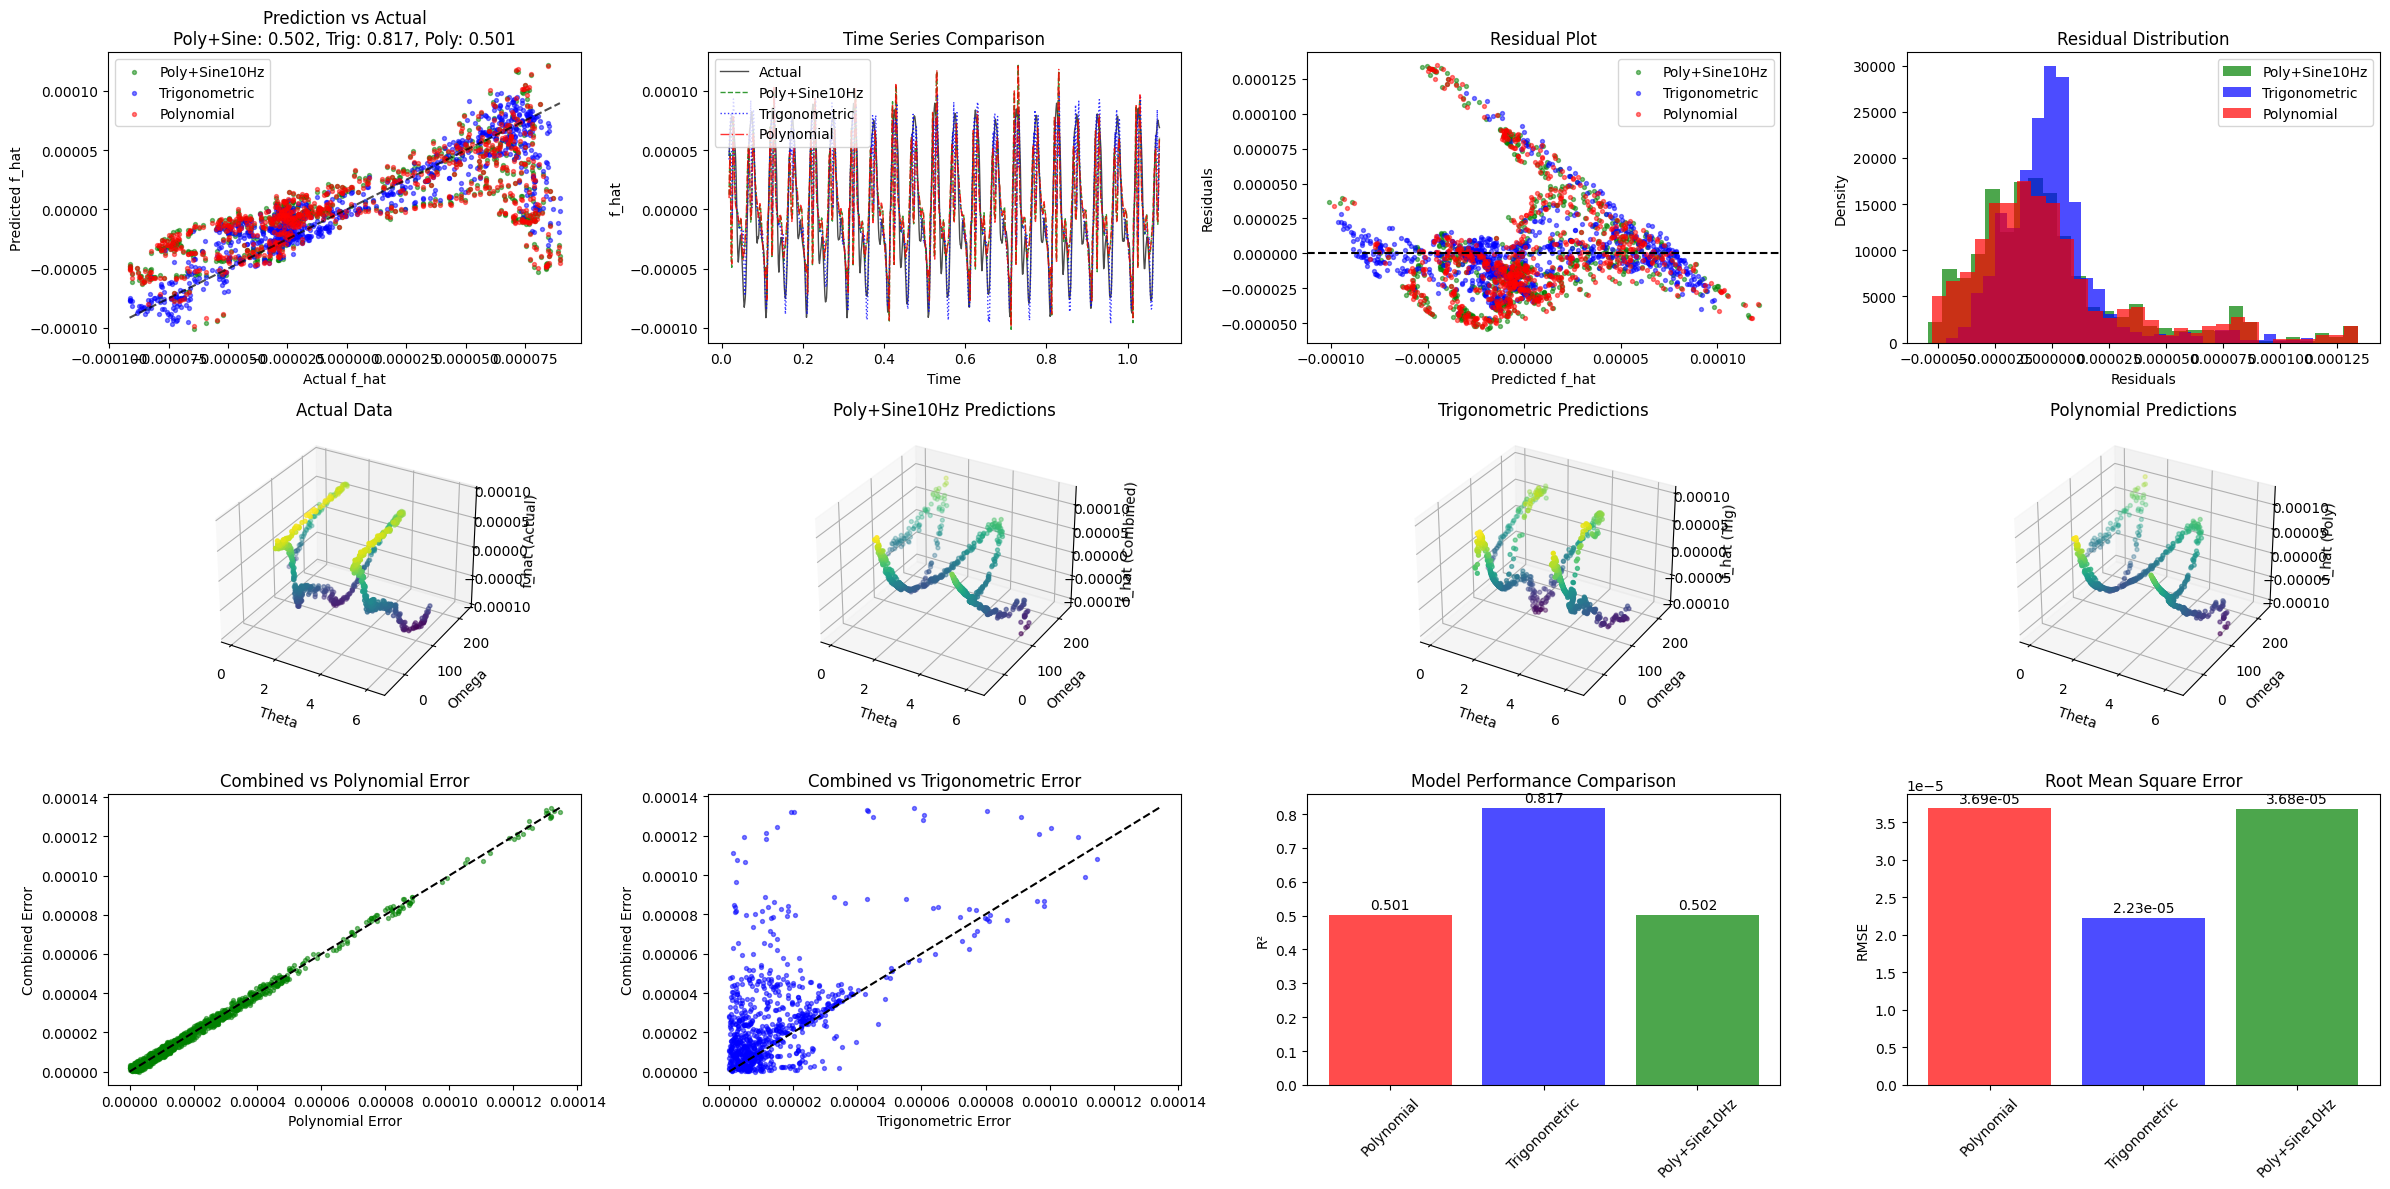


Detailed Summary Statistics:
Model                R²       RMSE         MAE          Max Error   
----------------------------------------------------------------------
Polynomial           0.5006   3.69e-05     2.65e-05     1.35e-04    
Trigonometric        0.8172   2.23e-05     1.46e-05     1.15e-04    
Poly+Sine10Hz        0.5019   3.68e-05     2.65e-05     1.34e-04    

✓ Trigonometric model is the best with R² = 0.8172


In [46]:
# Test the best polynomial + 10Hz sine model with visualizations
try:
    f_hat_predicted_combined = best_model_combined.predict(X_clean)
    print(f"Combined model prediction shape: {f_hat_predicted_combined.shape}")
    print(f"Original f_hat shape: {y_clean.shape}")
    
    # Calculate R-squared for all models
    r_squared_combined = r2_score(y_clean, f_hat_predicted_combined)
    f_hat_predicted_prev = best_model.predict(X_clean)
    r_squared_prev = r2_score(y_clean, f_hat_predicted_prev)
    f_hat_predicted_trig = best_model_trig.predict(X_clean)
    r_squared_trig = r2_score(y_clean, f_hat_predicted_trig)
    
    print(f"\nModel Performance Comparison:")
    print(f"Polynomial only: R² = {r_squared_prev:.4f}")
    print(f"Trigonometric (multi-freq): R² = {r_squared_trig:.4f}")
    print(f"Polynomial + 10Hz sine: R² = {r_squared_combined:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(24, 12))
    
    # Plot 1: Prediction vs Actual scatter plot
    plt.subplot(3, 4, 1)
    plt.scatter(y_clean, f_hat_predicted_combined, alpha=0.5, label='Poly+Sine10Hz', s=8, color='green')
    plt.scatter(y_clean, f_hat_predicted_trig, alpha=0.5, label='Trigonometric', s=8, color='blue')
    plt.scatter(y_clean, f_hat_predicted_prev, alpha=0.5, label='Polynomial', s=8, color='red')
    plt.plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], 'k--', alpha=0.7)
    plt.xlabel('Actual f_hat')
    plt.ylabel('Predicted f_hat')
    plt.title(f'Prediction vs Actual\nPoly+Sine: {r_squared_combined:.3f}, Trig: {r_squared_trig:.3f}, Poly: {r_squared_prev:.3f}')
    plt.legend()
    
    # Plot 2: Time series comparison
    plt.subplot(3, 4, 2)
    ts_clean = ts[1:][valid_mask]
    plt.plot(ts_clean, y_clean, 'k-', label='Actual', alpha=0.7, linewidth=1)
    plt.plot(ts_clean, f_hat_predicted_combined, 'g--', label='Poly+Sine10Hz', alpha=0.8, linewidth=1)
    plt.plot(ts_clean, f_hat_predicted_trig, 'b:', label='Trigonometric', alpha=0.8, linewidth=1)
    plt.plot(ts_clean, f_hat_predicted_prev, 'r-.', label='Polynomial', alpha=0.8, linewidth=1)
    plt.xlabel('Time')
    plt.ylabel('f_hat')
    plt.title('Time Series Comparison')
    plt.legend()
    
    # Plot 3: Residuals comparison
    plt.subplot(3, 4, 3)
    residuals_combined = y_clean - f_hat_predicted_combined
    residuals_trig = y_clean - f_hat_predicted_trig
    residuals_prev = y_clean - f_hat_predicted_prev
    
    plt.scatter(f_hat_predicted_combined, residuals_combined, alpha=0.5, label='Poly+Sine10Hz', s=8, color='green')
    plt.scatter(f_hat_predicted_trig, residuals_trig, alpha=0.5, label='Trigonometric', s=8, color='blue')
    plt.scatter(f_hat_predicted_prev, residuals_prev, alpha=0.5, label='Polynomial', s=8, color='red')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.xlabel('Predicted f_hat')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.legend()
    
    # Plot 4: Residuals histogram
    plt.subplot(3, 4, 4)
    plt.hist(residuals_combined, bins=30, alpha=0.7, label='Poly+Sine10Hz', density=True, color='green')
    plt.hist(residuals_trig, bins=30, alpha=0.7, label='Trigonometric', density=True, color='blue')
    plt.hist(residuals_prev, bins=30, alpha=0.7, label='Polynomial', density=True, color='red')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.title('Residual Distribution')
    plt.legend()
    
    # Plot 5: 3D scatter plot - Actual data
    ax1 = plt.subplot(3, 4, 5, projection='3d')
    scatter1 = ax1.scatter(X_clean[:, 0], X_clean[:, 1], y_clean, c=y_clean, cmap='viridis', s=8)
    ax1.set_xlabel('Theta')
    ax1.set_ylabel('Omega')
    ax1.set_zlabel('f_hat (Actual)')
    ax1.set_title('Actual Data')
    
    # Plot 6: 3D scatter plot - Combined predictions
    ax2 = plt.subplot(3, 4, 6, projection='3d')
    scatter2 = ax2.scatter(X_clean[:, 0], X_clean[:, 1], f_hat_predicted_combined, c=f_hat_predicted_combined, cmap='viridis', s=8)
    ax2.set_xlabel('Theta')
    ax2.set_ylabel('Omega')
    ax2.set_zlabel('f_hat (Combined)')
    ax2.set_title('Poly+Sine10Hz Predictions')
    
    # Plot 7: 3D scatter plot - Trigonometric predictions
    ax3 = plt.subplot(3, 4, 7, projection='3d')
    scatter3 = ax3.scatter(X_clean[:, 0], X_clean[:, 1], f_hat_predicted_trig, c=f_hat_predicted_trig, cmap='viridis', s=8)
    ax3.set_xlabel('Theta')
    ax3.set_ylabel('Omega')
    ax3.set_zlabel('f_hat (Trig)')
    ax3.set_title('Trigonometric Predictions')
    
    # Plot 8: 3D scatter plot - Polynomial predictions
    ax4 = plt.subplot(3, 4, 8, projection='3d')
    scatter4 = ax4.scatter(X_clean[:, 0], X_clean[:, 1], f_hat_predicted_prev, c=f_hat_predicted_prev, cmap='viridis', s=8)
    ax4.set_xlabel('Theta')
    ax4.set_ylabel('Omega')
    ax4.set_zlabel('f_hat (Poly)')
    ax4.set_title('Polynomial Predictions')
    
    # Plot 9: Error comparison - Combined vs Polynomial
    plt.subplot(3, 4, 9)
    error_combined = np.abs(residuals_combined)
    error_prev = np.abs(residuals_prev)
    plt.scatter(error_prev, error_combined, alpha=0.5, s=8, color='green')
    plt.plot([0, max(error_prev.max(), error_combined.max())], [0, max(error_prev.max(), error_combined.max())], 'k--')
    plt.xlabel('Polynomial Error')
    plt.ylabel('Combined Error')
    plt.title('Combined vs Polynomial Error')
    
    # Plot 10: Error comparison - Combined vs Trigonometric
    plt.subplot(3, 4, 10)
    error_trig = np.abs(residuals_trig)
    plt.scatter(error_trig, error_combined, alpha=0.5, s=8, color='blue')
    plt.plot([0, max(error_trig.max(), error_combined.max())], [0, max(error_trig.max(), error_combined.max())], 'k--')
    plt.xlabel('Trigonometric Error')
    plt.ylabel('Combined Error')
    plt.title('Combined vs Trigonometric Error')
    
    # Plot 11: R² comparison bar chart
    plt.subplot(3, 4, 11)
    models = ['Polynomial', 'Trigonometric', 'Poly+Sine10Hz']
    r2_values = [r_squared_prev, r_squared_trig, r_squared_combined]
    colors = ['red', 'blue', 'green']
    bars = plt.bar(models, r2_values, color=colors, alpha=0.7)
    plt.ylabel('R²')
    plt.title('Model Performance Comparison')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, r2_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{value:.3f}', 
                ha='center', va='bottom')
    
    # Plot 12: RMSE comparison
    plt.subplot(3, 4, 12)
    rmse_values = [np.sqrt(np.mean(residuals_prev**2)), 
                   np.sqrt(np.mean(residuals_trig**2)), 
                   np.sqrt(np.mean(residuals_combined**2))]
    bars = plt.bar(models, rmse_values, color=colors, alpha=0.7)
    plt.ylabel('RMSE')
    plt.title('Root Mean Square Error')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, rmse_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_values)*0.01, f'{value:.2e}', 
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nDetailed Summary Statistics:")
    print(f"{'Model':<20} {'R²':<8} {'RMSE':<12} {'MAE':<12} {'Max Error':<12}")
    print("-" * 70)
    
    for name, pred, res in [('Polynomial', f_hat_predicted_prev, residuals_prev),
                           ('Trigonometric', f_hat_predicted_trig, residuals_trig),
                           ('Poly+Sine10Hz', f_hat_predicted_combined, residuals_combined)]:
        r2 = r2_score(y_clean, pred)
        rmse = np.sqrt(np.mean(res**2))
        mae = np.mean(np.abs(res))
        max_err = np.max(np.abs(res))
        print(f"{name:<20} {r2:<8.4f} {rmse:<12.2e} {mae:<12.2e} {max_err:<12.2e}")
    
    # Show which model is best
    best_r2 = max(r_squared_prev, r_squared_trig, r_squared_combined)
    if best_r2 == r_squared_combined:
        print(f"\n✓ Poly+Sine10Hz model is the best with R² = {best_r2:.4f}")
    elif best_r2 == r_squared_trig:
        print(f"\n✓ Trigonometric model is the best with R² = {best_r2:.4f}")
    else:
        print(f"\n✓ Polynomial model is the best with R² = {best_r2:.4f}")
    
except Exception as e:
    print(f"Error in model comparison: {e}")
    print(f"Best combined model: {best_name_combined}")
    print(f"X_clean shape: {X_clean.shape}, y_clean shape: {y_clean.shape}")


In [6]:
# Frequency sweep: add time-based sine features (1–20 Hz) and plot performance
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

class SineHzTimeFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, freqs_hz, ts):
        self.freqs_hz = list(freqs_hz)
        self.ts = np.asarray(ts)
    def fit(self, X, y=None):
        if len(self.ts) != X.shape[0]:
            raise ValueError("Length of ts must match number of rows in X")
        return self
    def transform(self, X):
        features = [X]
        t = self.ts
        for f in self.freqs_hz:
            w = 2 * np.pi * f
            features.append(np.sin(w * t))  # sine only as requested
        return np.column_stack(features)

# Use cleaned time indices aligned with X_clean / y_clean
ts_clean = ts[1:][valid_mask]

freqs_hz = list(range(1, 21))
r2_by_freq = []
models_by_freq = {}

for f in freqs_hz:
    model_f = Pipeline([
        ('sine', SineHzTimeFeatures(freqs_hz=[f], ts=ts_clean)),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1e-3)),
    ])
    model_f.fit(X_clean, y_clean)
    y_pred_f = model_f.predict(X_clean)
    r2_f = r2_score(y_clean, y_pred_f)
    r2_by_freq.append(r2_f)
    models_by_freq[f] = model_f

best_idx = int(np.argmax(r2_by_freq))
best_freq_hz = freqs_hz[best_idx]
best_model_sine_sweep = models_by_freq[best_freq_hz]
print(f"Best frequency: {best_freq_hz} Hz with R² = {r2_by_freq[best_idx]:.4f}")

# Also compute baselines if available
try:
    r2_poly_only = r2_score(y_clean, best_model.predict(X_clean))
except Exception:
    r2_poly_only = None
try:
    r2_trig_multi = r2_score(y_clean, best_model_trig.predict(X_clean))
except Exception:
    r2_trig_multi = None

# Plot R² vs frequency
plt.figure(figsize=(10, 4))
plt.plot(freqs_hz, r2_by_freq, 'o-', label='Poly + sin(2πft)')
if r2_poly_only is not None:
    plt.axhline(r2_poly_only, color='r', ls='--', alpha=0.6, label='Polynomial only R²')
if r2_trig_multi is not None:
    plt.axhline(r2_trig_multi, color='b', ls=':', alpha=0.6, label='Trig (multi-freq) R²')
plt.axvline(best_freq_hz, color='g', ls='--', alpha=0.6, label=f'Best f = {best_freq_hz} Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('R²')
plt.title('R² vs sine frequency (Poly + sin(2πft))')
plt.legend()
plt.tight_layout()
plt.show()

# Update the combined model reference so the comparison cell can use it
best_model_combined = best_model_sine_sweep

# Quick preview plot for best frequency
y_pred_best = best_model_combined.predict(X_clean)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_clean, y_pred_best, s=8, alpha=0.6)
lims = [min(y_clean.min(), y_pred_best.min()), max(y_clean.max(), y_pred_best.max())]
plt.plot(lims, lims, 'k--', alpha=0.7)
plt.xlabel('Actual f_hat')
plt.ylabel('Predicted f_hat')
plt.title(f'Best freq {best_freq_hz} Hz: R²={r2_by_freq[best_idx]:.3f}')

plt.subplot(1, 2, 2)
plt.plot(ts_clean, y_clean, 'k-', lw=1, alpha=0.7, label='Actual')
plt.plot(ts_clean, y_pred_best, 'g--', lw=1, alpha=0.8, label='Poly+sin(2πft)')
plt.xlabel('Time')
plt.ylabel('f_hat')
plt.title('Time series (best freq)')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'valid_mask' is not defined